In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score
   

KeyboardInterrupt: 

In [ ]:
df = pd.read_excel("Dry_Bean_Dataset\Dry_Bean_Dataset.xlsx")
df.head(5)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [ ]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [ ]:
## Drop Duplicates

df.drop_duplicates(inplace=True)


In [ ]:
## Checking Null Dataset

df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [ ]:
## Melihat Distribusi Dataset
tdf = df['Class'].value_counts().reset_index()
tdf

,Class,count
0,DERMASON,3546
1,SIRA,2636
2,SEKER,2027
3,HOROZ,1860
4,CALI,1630
5,BARBUNYA,1322
6,BOMBAY,522


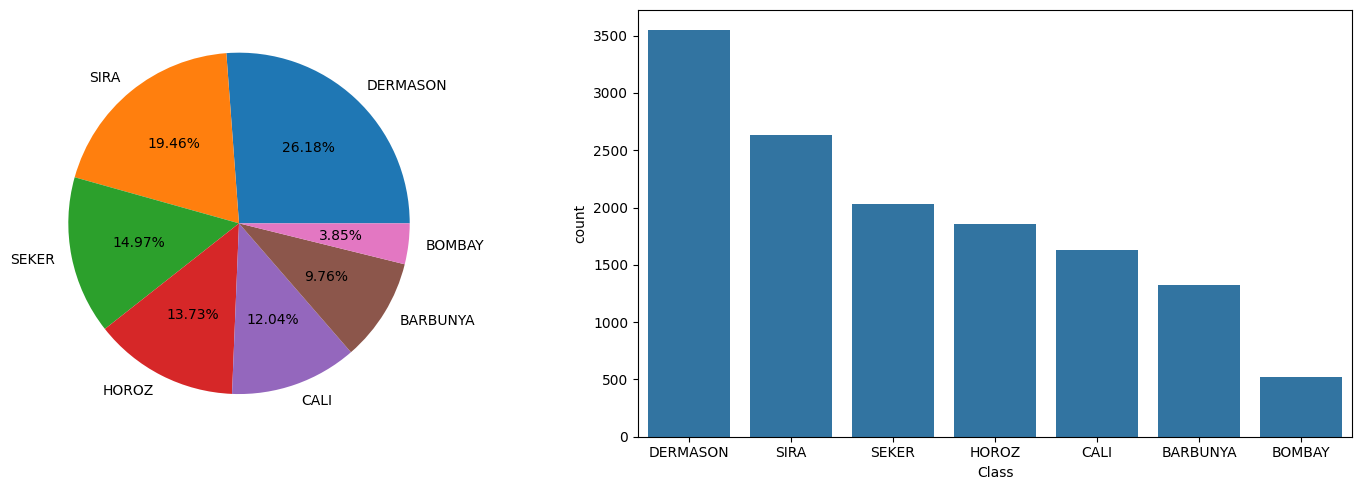

In [ ]:
## VIsualisasi Sebaran Data target dalam Dataset ini (PENTING KARENA DAPAT MENGAKIBATKAN OVERFITTING)
fig, ax= plt.subplots(1, 2, figsize=(15, 5))
# Pie Chart
ax[0].pie(labels=tdf['Class'], x=tdf['count'], autopct='%.2f%%')
# Bar Plot
sns.barplot(data=tdf, x=tdf['Class'], y=tdf['count'], ax=ax[1])
plt.tight_layout()
plt.show()

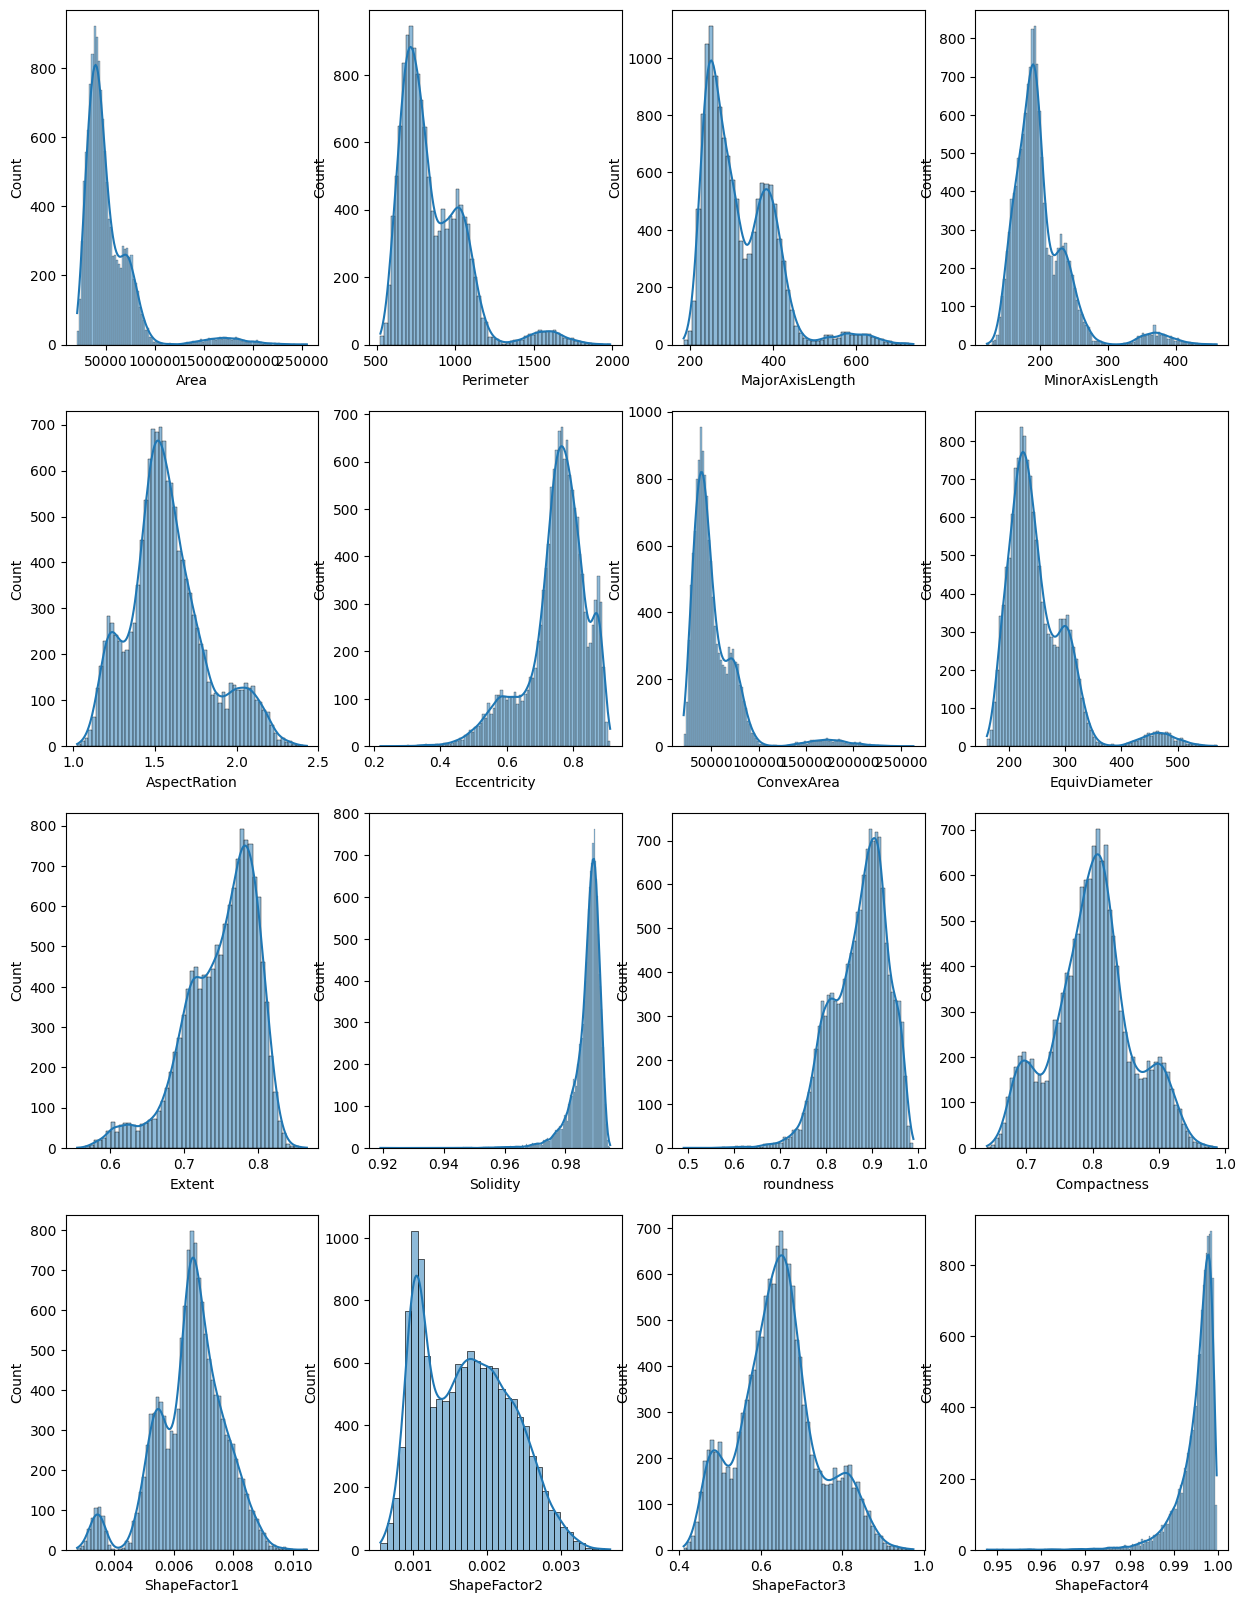

In [ ]:

## Kita melihat Selisih Distribusi data terbanyak dan terdikit sangat jauh
## DImana 26% - 4% yaitu 20%
## Kita liat sebaran data fitur, untuk menentukan bagaimana preprocessingnya. Dan model yang digunakan

fig,ax=plt.subplots(4,4,figsize=(15,20)) # 4 X 4 subplots
ax=ax.flatten()
i=0
for col in df.columns[df.columns!='Class']:
    sns.histplot(data=df,x=col,ax=ax[i],kde=True)
    i+=1

C:\Users\user\AppData\Local\Temp\ipykernel_8824\114998821.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


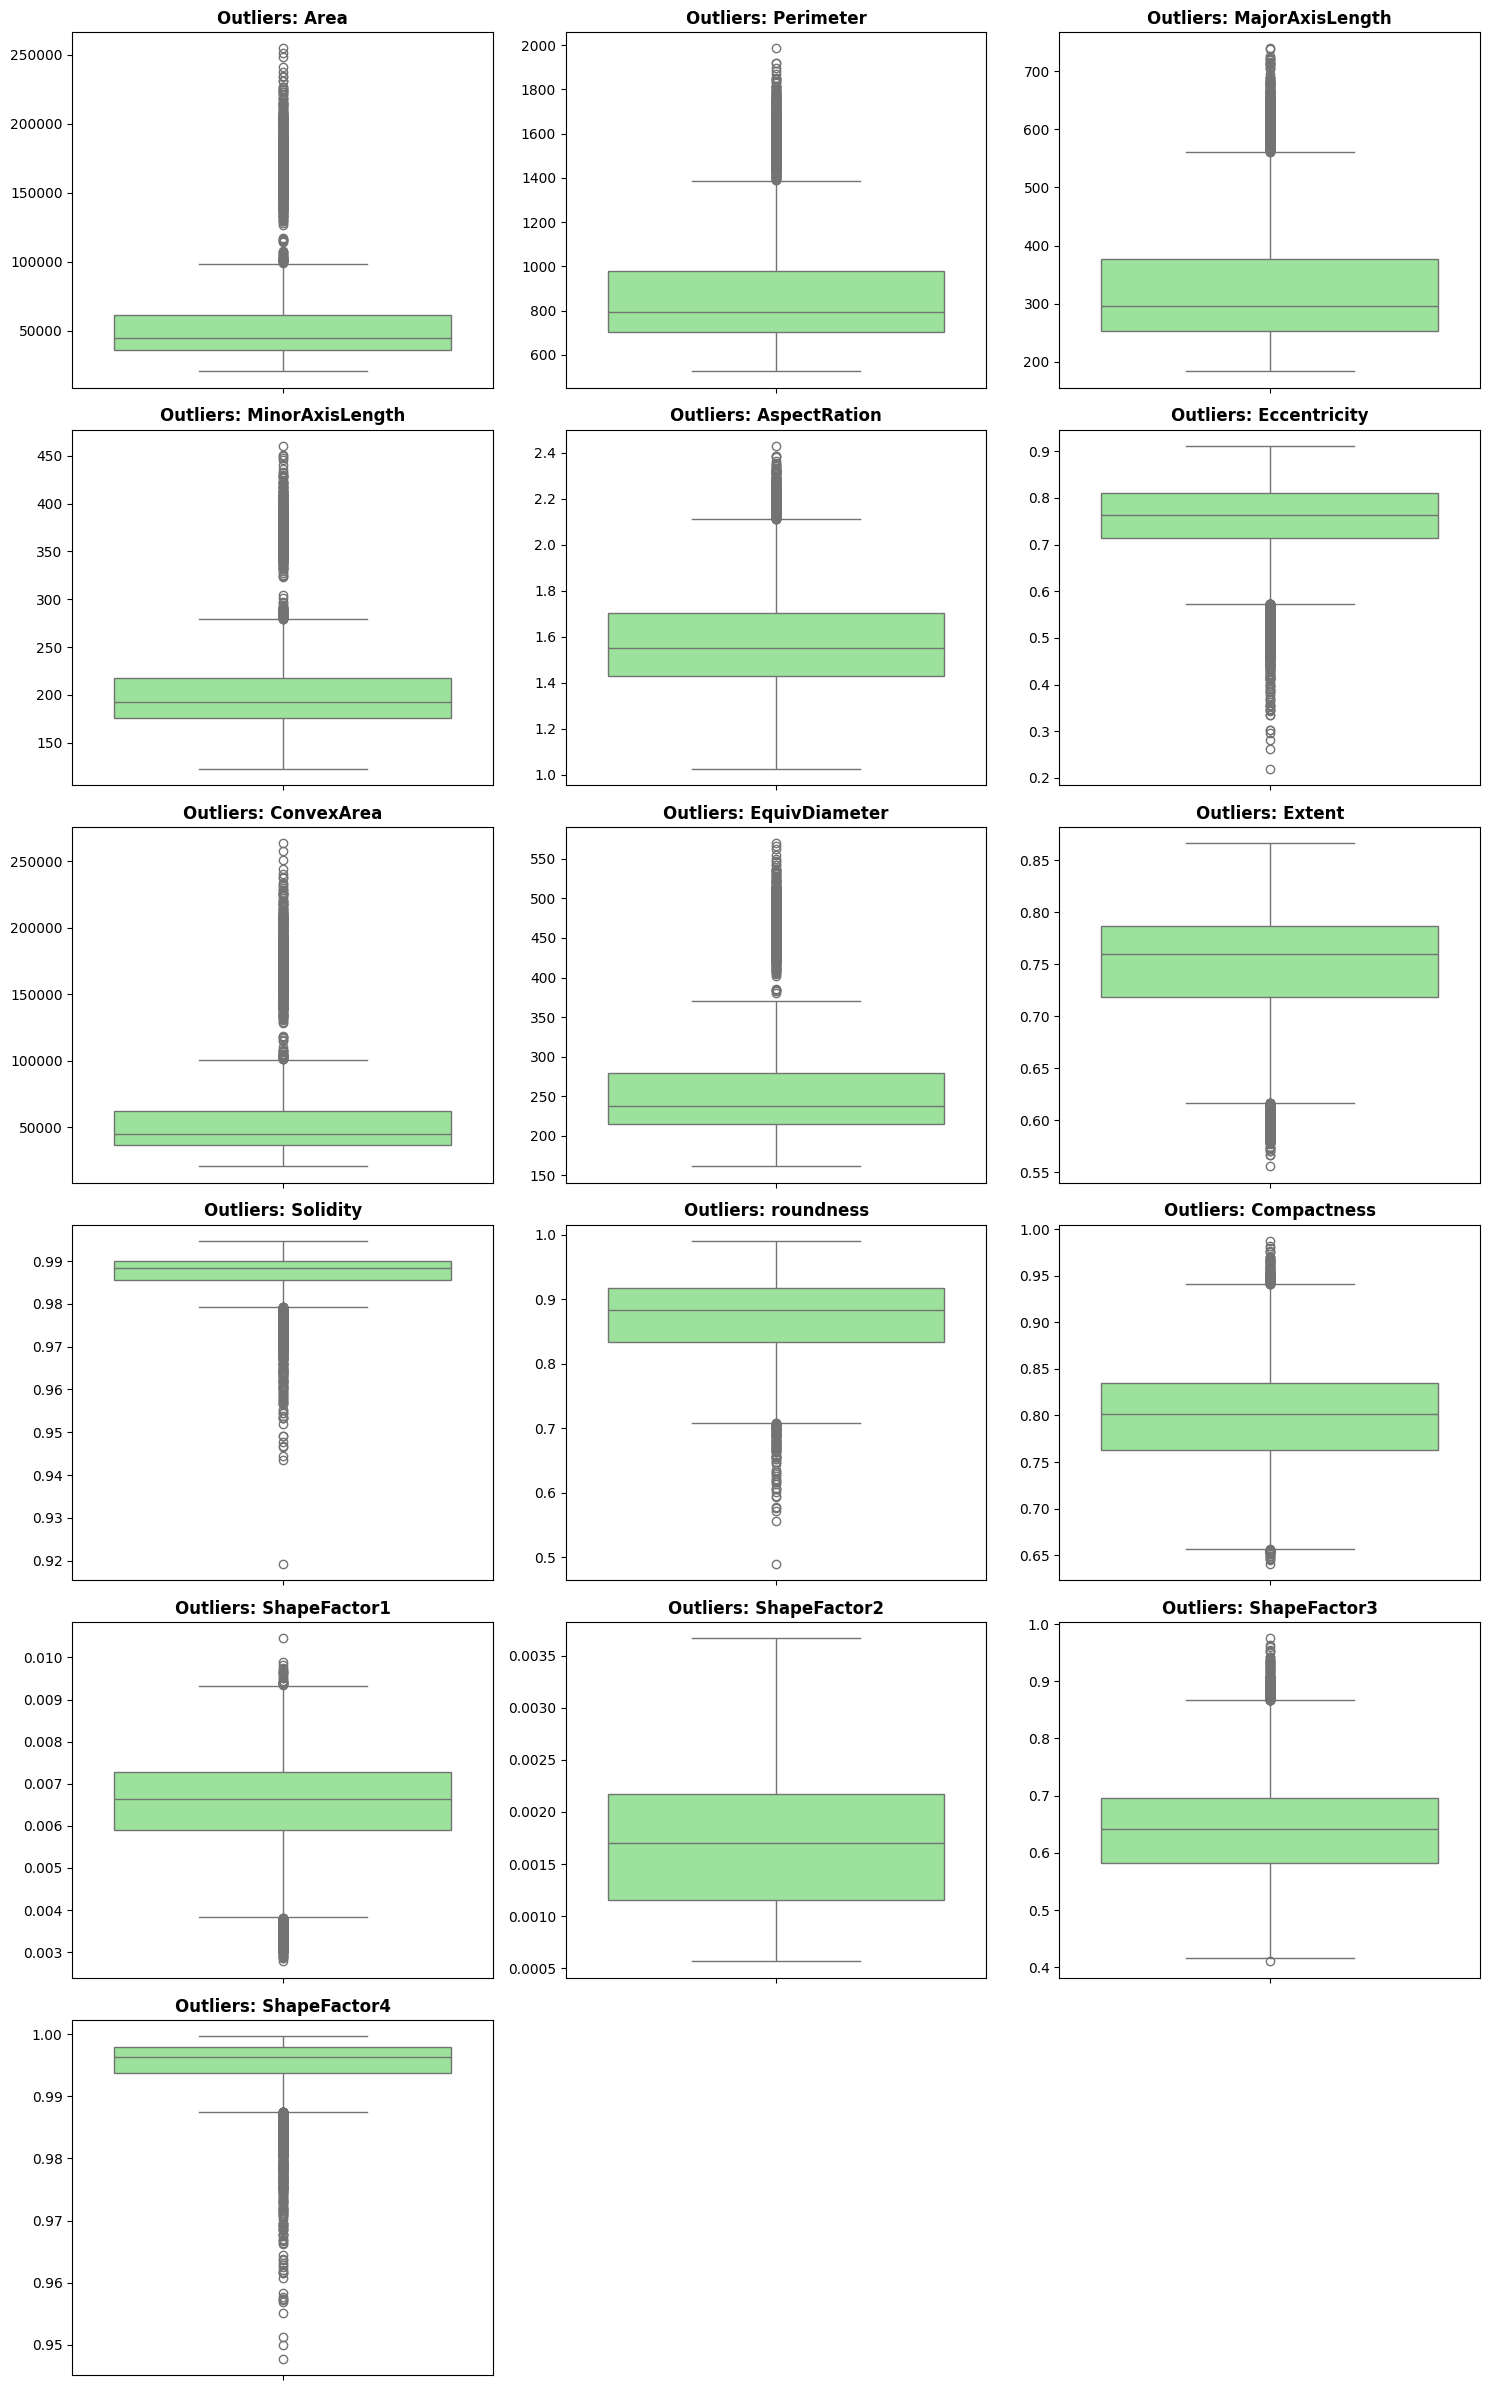

In [ ]:
## Checking Outliers

import pandas as pd
import math

numeric_features = df.select_dtypes(include=['number']).columns
categorical_features = df.select_dtypes(include=['object']).columns

jumlah_fitur = len(numeric_features)

# 2. Atur tata letak grid (misal: 3 kolom per baris)
kolom_grid = 3
baris_grid = math.ceil(jumlah_fitur / kolom_grid)

# 3. Buat kanvas (figure) dan kotak-kotaknya (axes)
# figsize diatur dinamis: lebar 15, tinggi menyesuaikan jumlah baris
fig, axes = plt.subplots(baris_grid, kolom_grid, figsize=(15, 4 * baris_grid))
axes = axes.flatten() # Ratakan array kotak agar mudah diisi pakai loop

# 4. Looping untuk menggambar boxplot Seaborn ke dalam masing-masing kotak
for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Outliers: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Sembunyikan label Y agar UI lebih bersih

# 5. Hapus kotak sisa yang kosong (jika total fitur Anda bukan kelipatan 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Rapikan jarak antar kotak dan tampilkan
plt.tight_layout()
plt.show()

In [ ]:
## Handle Outliers
## Using Capping Method

def cap_outliers_efficient(df, columns):
    df_capped = df.copy() # Membuat salinan agar data asli tidak rusak
    
    for col in columns:
        # Menentukan batas bawah (persentil 5%) dan atas (persentil 95%)
        lower_bound = df_capped[col].quantile(0.05)
        upper_bound = df_capped[col].quantile(0.95)
        
        # Fungsi clip() akan otomatis membatasi nilai yang kelebihan/kekurangan
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_capped

# Penggunaan:
df = cap_outliers_efficient(df, numeric_features)

C:\Users\user\AppData\Local\Temp\ipykernel_8824\2961088535.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


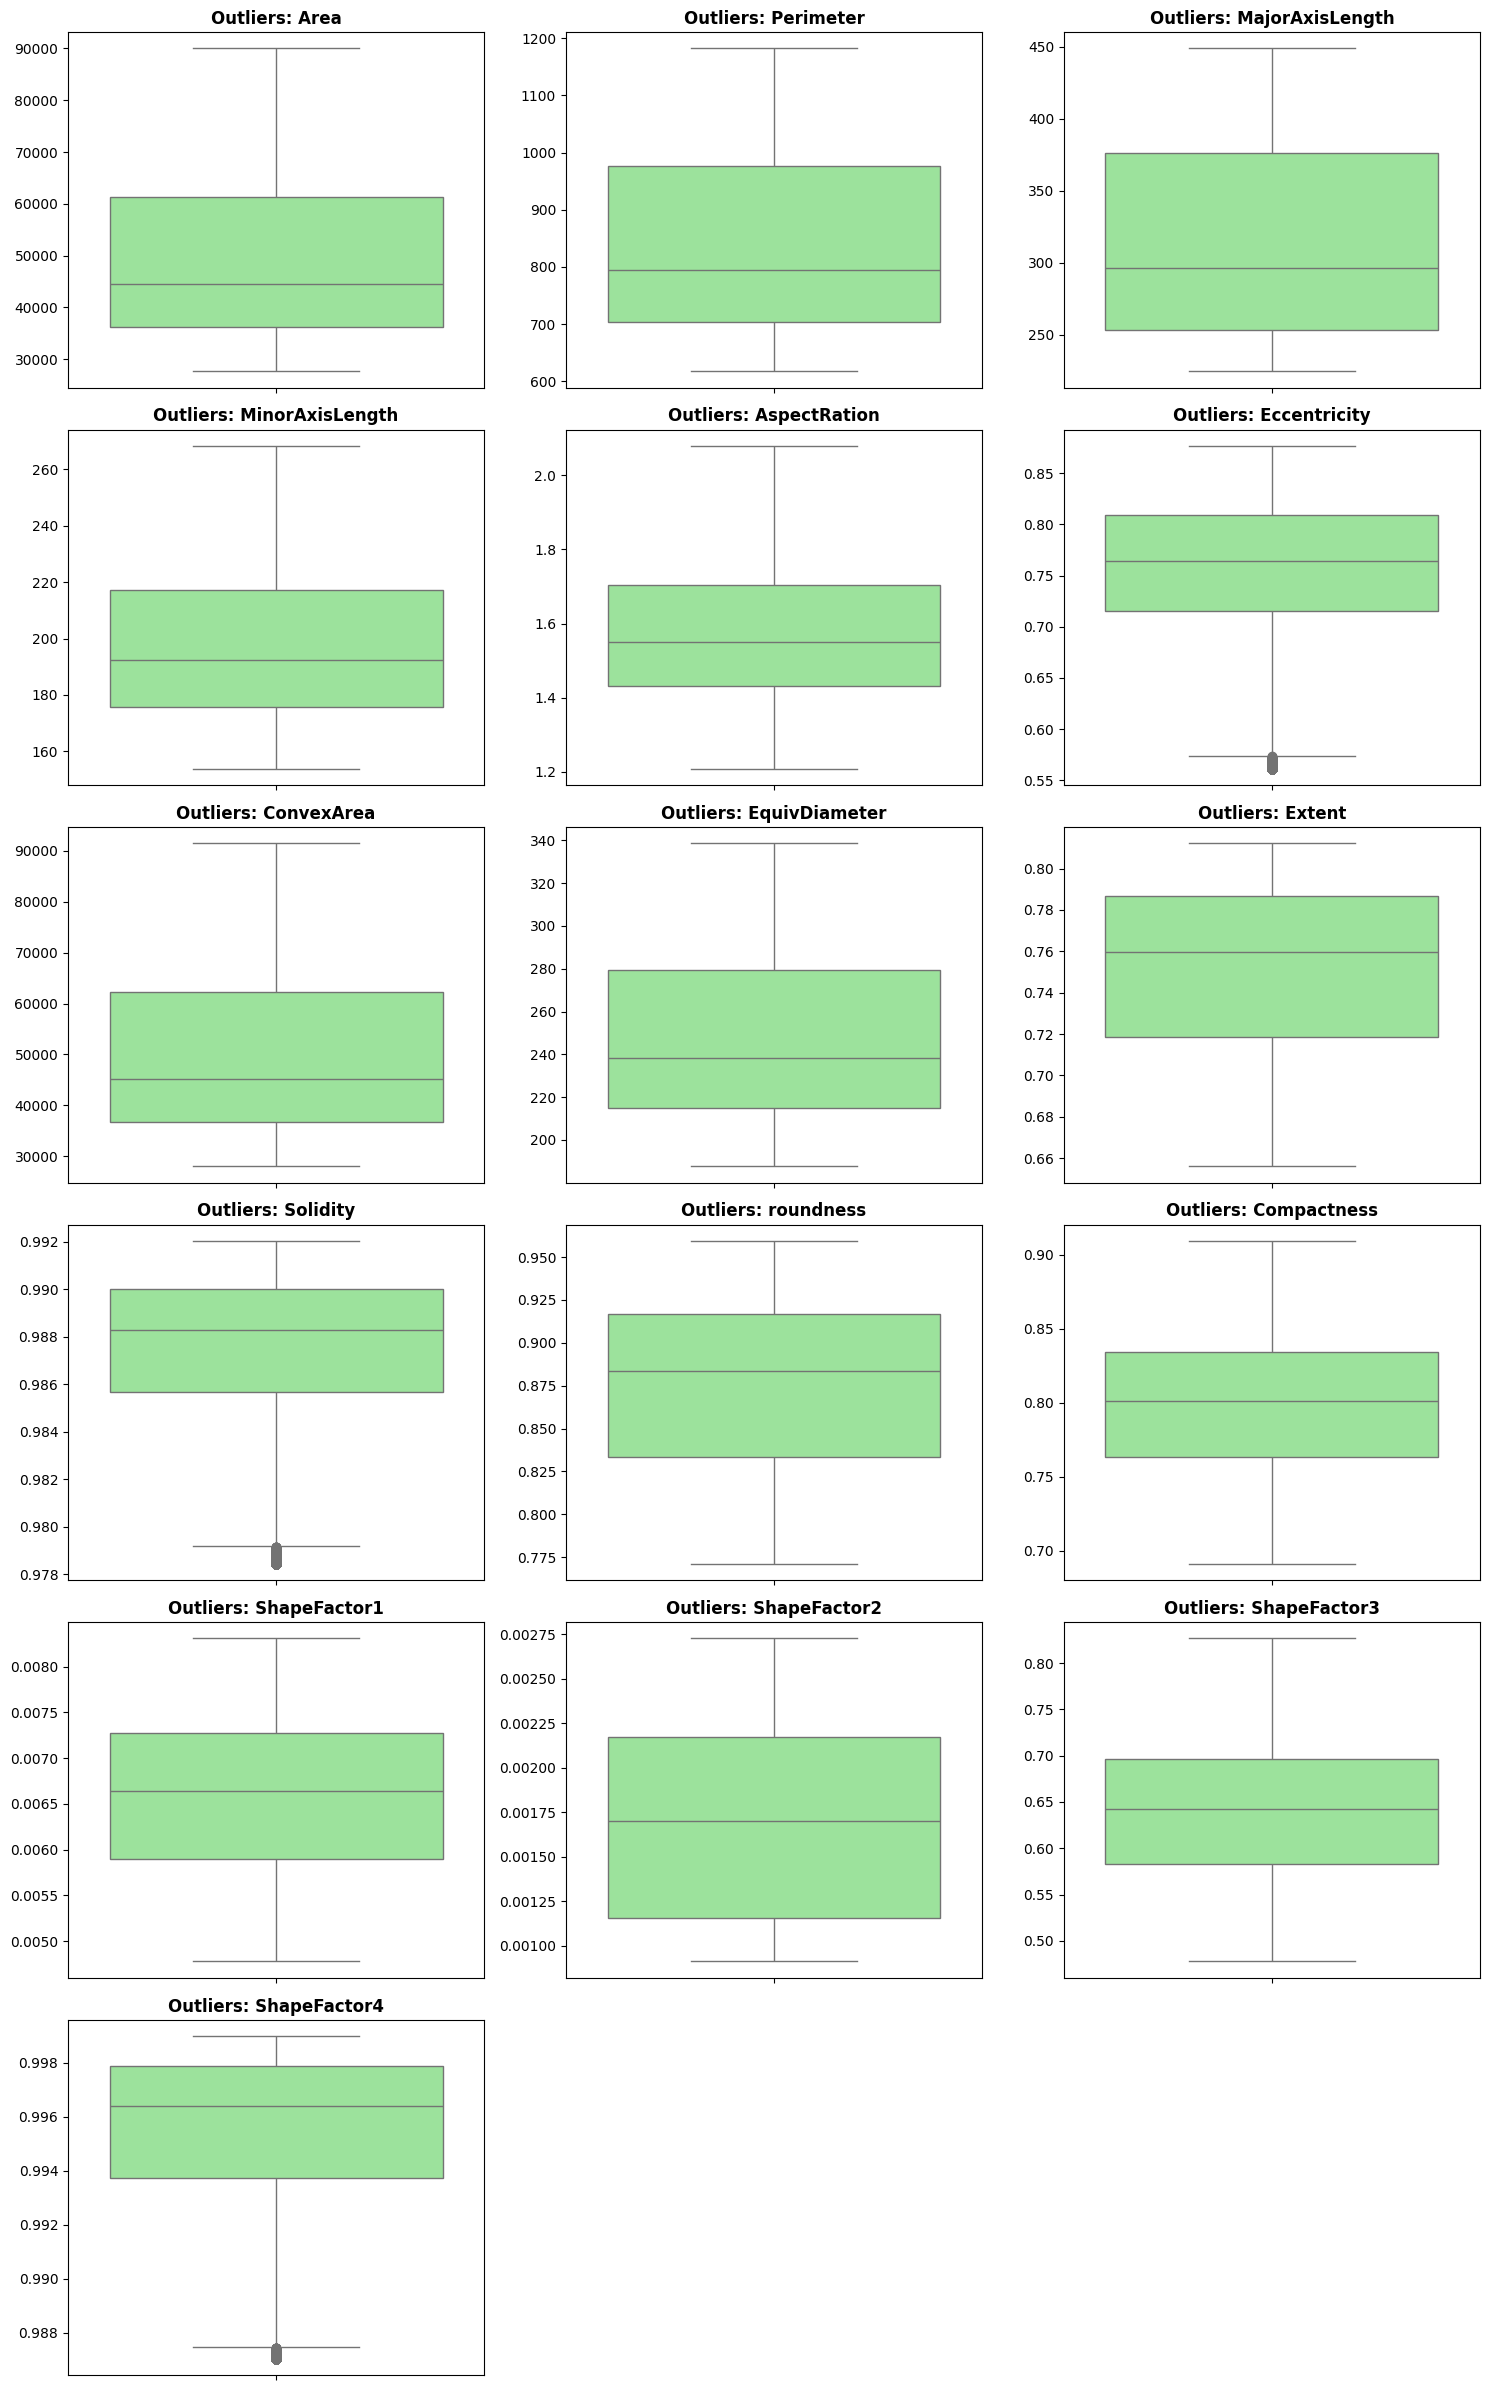

In [ ]:
## Outliers Feature After handling

## Checking Outliers

import pandas as pd
import math

numeric_features = df.select_dtypes(include=['number']).columns
categorical_features = df.select_dtypes(include=['object']).columns

jumlah_fitur = len(numeric_features)

# 2. Atur tata letak grid (misal: 3 kolom per baris)
kolom_grid = 3
baris_grid = math.ceil(jumlah_fitur / kolom_grid)

# 3. Buat kanvas (figure) dan kotak-kotaknya (axes)
# figsize diatur dinamis: lebar 15, tinggi menyesuaikan jumlah baris
fig, axes = plt.subplots(baris_grid, kolom_grid, figsize=(15, 4 * baris_grid))
axes = axes.flatten() # Ratakan array kotak agar mudah diisi pakai loop

# 4. Looping untuk menggambar boxplot Seaborn ke dalam masing-masing kotak
for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Outliers: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Sembunyikan label Y agar UI lebih bersih

# 5. Hapus kotak sisa yang kosong (jika total fitur Anda bukan kelipatan 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Rapikan jarak antar kotak dan tampilkan
plt.tight_layout()
plt.show()

In [ ]:
## Karena Semua tipe data pada fiturnya sudah berbentuk Numerik tidak perlu ENcoding untuk FItur
## Tipe Data dari Targetnya masih dalam bentuk STR, Berarti Perlu Encoding.

label_encoder= LabelEncoder()
categoric_features = ["Class"]

for col in categoric_features:
    df[col] = label_encoder.fit_transform(df[col])
    
df["Class"].unique()

array([5, 0, 1, 2, 4, 6, 3])

In [ ]:
df.head(5)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,617.4091,224.604232,173.888747,1.207922,0.560923,28715.0,190.141097,0.763923,0.988856,0.958027,0.909193,0.007332,0.002727,0.826631,0.998724,5
1,28734.0,638.0180,224.604232,182.734419,1.207922,0.560923,29172.0,191.272750,0.783968,0.984986,0.887034,0.909193,0.006979,0.002727,0.826631,0.998430,5
2,29380.0,624.1100,224.604232,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.002727,0.825871,0.998993,5
3,30008.0,645.8840,224.604232,182.516516,1.207922,0.560923,30724.0,195.467062,0.782681,0.978436,0.903936,0.909193,0.007017,0.002727,0.826631,0.994199,5
4,30140.0,620.1340,224.604232,190.279279,1.207922,0.560923,30417.0,195.896503,0.773098,0.990893,0.959403,0.909193,0.006697,0.002727,0.826631,0.998993,5


In [ ]:
## SPlit data into Feature and Target

X = df.drop(columns='Class')
y= df['Class']

y.value_counts()

Class
3    3546
6    2636
5    2027
4    1860
2    1630
0    1322
1     522
Name: count, dtype: int64

In [ ]:
## Karena Distribusi dari Target itu sangat tidak Seimbang Kita akan Apply Metode SMOTE
## Metode SMOTE  akan membuat data sintesis untuk menyeimbangkan fitur minoritas
# Let us apply SMOTE to balace the classes
# importing 
from imblearn.over_sampling import SMOTE

smote=SMOTE(sampling_strategy='auto',random_state=20) # Balancing all classes equally
xr,yr=smote.fit_resample(X,y) # Resampling
ndf=pd.DataFrame(xr,columns=X.columns) # Creating new dataframe 
ndf['Class']=yr
print(ndf['Class'].value_counts())

Class
5    3546
0    3546
1    3546
2    3546
4    3546
6    3546
3    3546
Name: count, dtype: int64


In [ ]:
ndf.shape
ndf.info()

<class 'pandas.DataFrame'>
RangeIndex: 24822 entries, 0 to 24821
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             24822 non-null  float64
 1   Perimeter        24822 non-null  float64
 2   MajorAxisLength  24822 non-null  float64
 3   MinorAxisLength  24822 non-null  float64
 4   AspectRation     24822 non-null  float64
 5   Eccentricity     24822 non-null  float64
 6   ConvexArea       24822 non-null  float64
 7   EquivDiameter    24822 non-null  float64
 8   Extent           24822 non-null  float64
 9   Solidity         24822 non-null  float64
 10  roundness        24822 non-null  float64
 11  Compactness      24822 non-null  float64
 12  ShapeFactor1     24822 non-null  float64
 13  ShapeFactor2     24822 non-null  float64
 14  ShapeFactor3     24822 non-null  float64
 15  ShapeFactor4     24822 non-null  float64
 16  Class            24822 non-null  int64  
dtypes: float64(16), int64(1

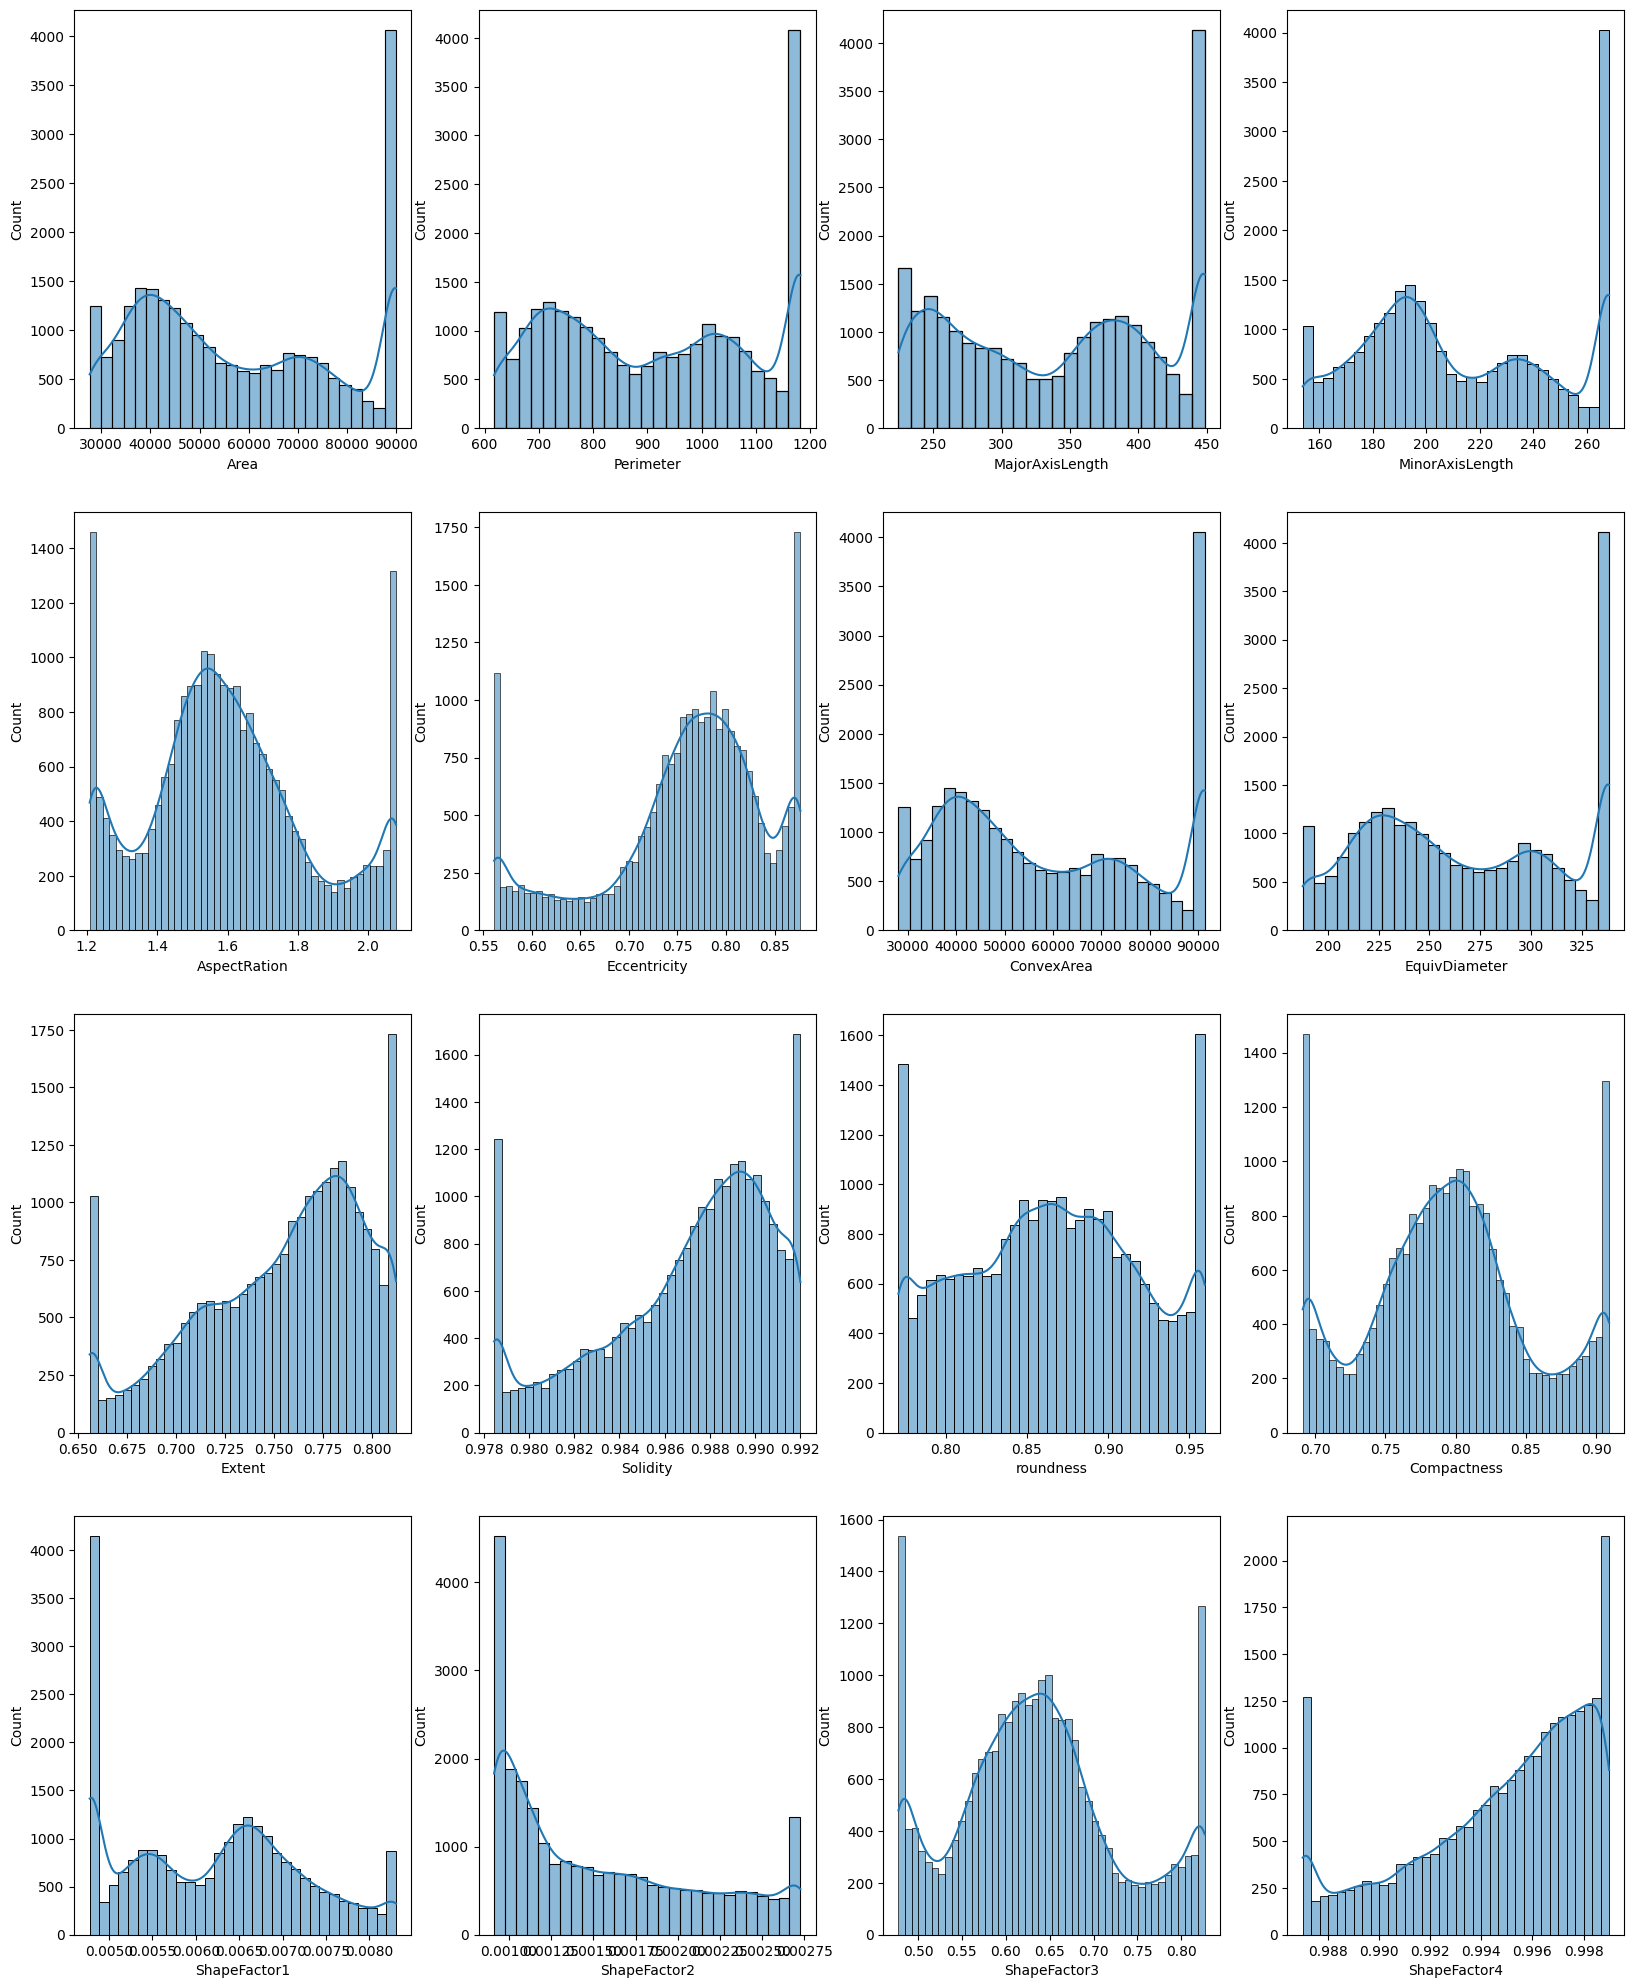

In [ ]:

## Kita melihat Selisih Distribusi data terbanyak dan terdikit sangat jauh
## DImana 26% - 4% yaitu 20%
## Kita liat sebaran data fitur, untuk menentukan bagaimana preprocessingnya. Dan model yang digunakan

fig,ax=plt.subplots(4,4,figsize=(20,25)) # 4 X 4 subplots
ax=ax.flatten()
i=0
for col in ndf.columns[ndf.columns!='Class']:
    sns.histplot(data=ndf,x=col,ax=ax[i],kde=True)
    i+=1
    

In [ ]:
## Split Dataset into Train and Test
ss = StandardScaler()
(X_train, X_test, y_train, y_test) = train_test_split(X, y,test_size=0.2, train_size=0.8)

## Normalisasi Fitur
## Karena Sudah berbentuk numeric semua

numeric_features = X_train.select_dtypes(include=["int64", 'float64']).columns
print(numeric_features)
X_train[numeric_features] = ss.fit_transform(X_train[numeric_features])
X_test[numeric_features]= ss.transform(X_test[numeric_features])



Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='str')


In [ ]:

for i in numeric_features:
    print(i, "mean: ", X_train[i].mean(), "std: ", X_train[i].std())

    

Area mean:  1.0493523880525755e-17 std:  1.0000461542012105
Perimeter mean:  -3.384161451469556e-16 std:  1.0000461542012107
MajorAxisLength mean:  -3.5677981193787565e-16 std:  1.000046154201211
MinorAxisLength mean:  3.889162288219858e-16 std:  1.0000461542012107
AspectRation mean:  1.4100672714456483e-15 std:  1.000046154201211
Eccentricity mean:  -4.564682888028704e-16 std:  1.0000461542012107
ConvexArea mean:  2.4003935876702664e-16 std:  1.0000461542012107
EquivDiameter mean:  -9.575340540979752e-17 std:  1.0000461542012107
Extent mean:  5.391047893620107e-16 std:  1.0000461542012107
Solidity mean:  -1.7541236856783866e-14 std:  1.0000461542012107
roundness mean:  2.3531727302079006e-15 std:  1.000046154201211
Compactness mean:  -5.377930988769449e-16 std:  1.0000461542012107
ShapeFactor1 mean:  -1.9413019178972648e-16 std:  1.0000461542012107
ShapeFactor2 mean:  1.2723397705137478e-16 std:  1.0000461542012107
ShapeFactor3 mean:  -4.945073128697762e-16 std:  1.0000461542012107
Sh

In [ ]:
# Define and Calculation Mutual Information

from sklearn.feature_selection import mutual_info_classif

mi=mutual_info_classif(X,y)
mi_df=pd.DataFrame({'Mutual Information':mi,'Features':X.columns})
mi_df.sort_values(by='Mutual Information',ascending=False,inplace=True)


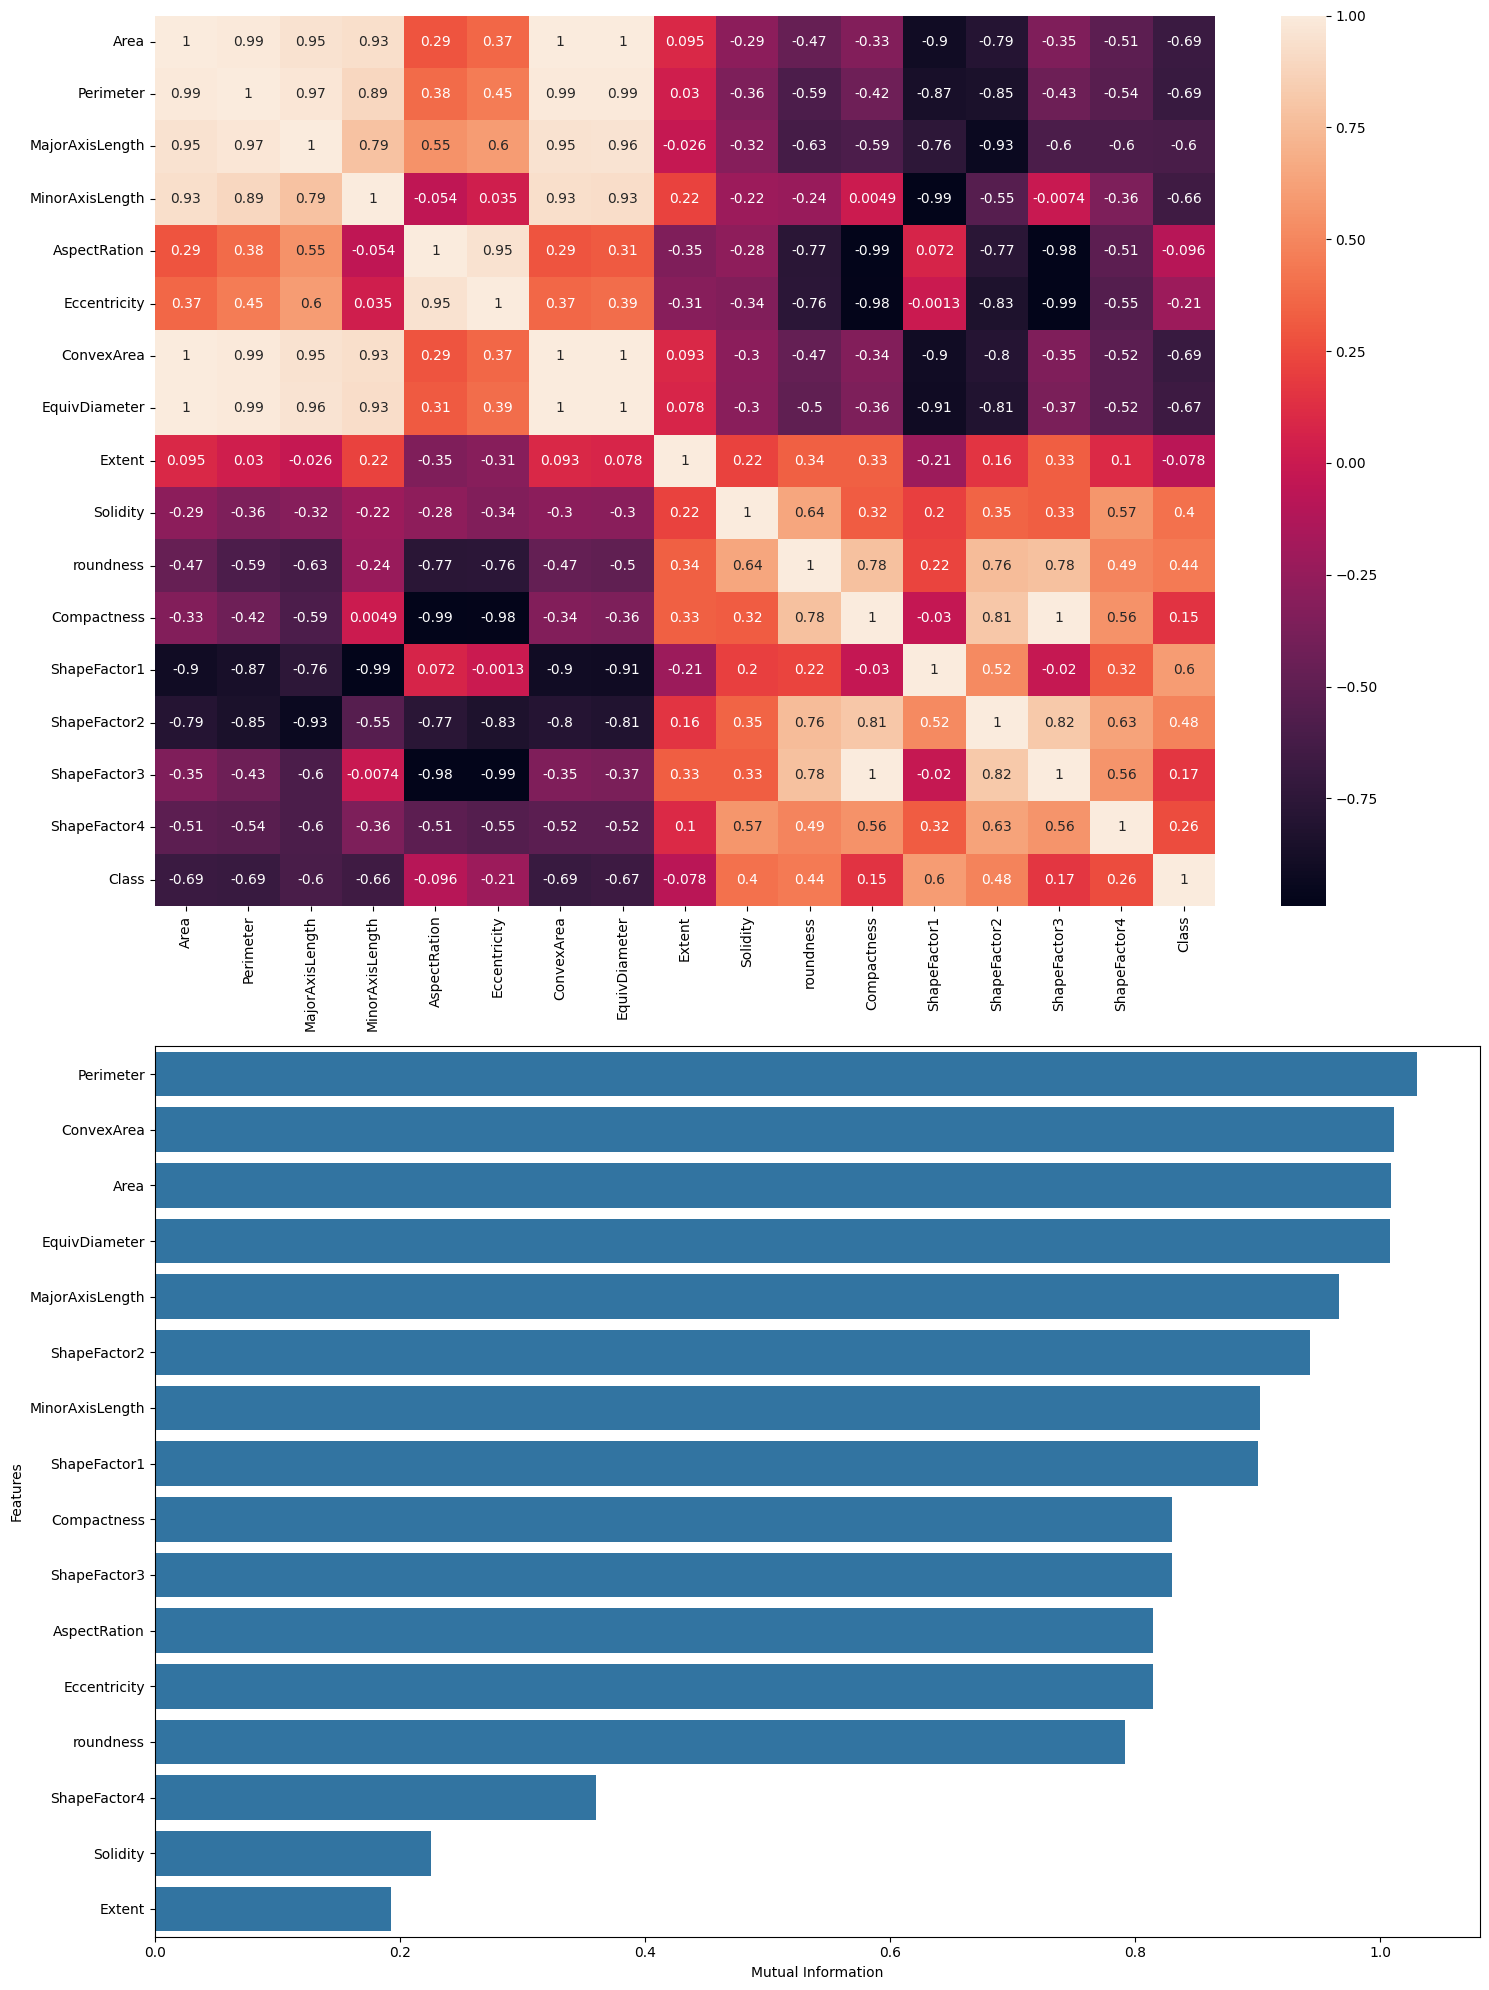

In [ ]:
# Visualize correlation and Mutual Information
fig,ax=plt.subplots(2,1,figsize=(15,20))
sns.heatmap(ndf.corr(),annot=True,ax=ax[0])
sns.barplot(data=mi_df,x='Mutual Information',y='Features')
plt.tight_layout()
plt.show()

In [ ]:
# Model LOAD

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)


In [ ]:
# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai kamus
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # tn, fp, fn, tp dihapus karena tidak bisa diterapkan langsung pada multi-class
    
    results = {
        'Confusion Matrix': cm,
        'Accuracy': accuracy_score(y_test, y_pred),
        # Tambahkan average='weighted' untuk menangani multi-class yang imbalanced
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    }
    return results

# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test)
}

# Buat DataFrame untuk meringkas hasil (looping Anda sebelumnya sudah sangat bagus!)
rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })

# Konversi daftar kamus ke DataFrame
summary_df = pd.DataFrame(rows)

# Tampilkan DataFrame
print(summary_df)

                          Model  Accuracy  Precision    Recall  F1-Score
0     K-Nearest Neighbors (KNN)  0.914729   0.915106  0.914729  0.914802
1            Decision Tree (DT)  0.890735   0.891171  0.890735  0.890887
2            Random Forest (RF)  0.920635   0.920499  0.920635  0.920518
3  Support Vector Machine (SVM)  0.923219   0.923685  0.923219  0.923291
4              Naive Bayes (NB)  0.897379   0.898823  0.897379  0.897436
